# **Diplomado IA: Audio y Video - Parte 1**. <br> Práctico 1: Introducción al Análisis de Audio
---
---

**Profesores:**
- Alain Raymond
- Gabriel Sepúlveda

**Ayudante:**
- Andreina Cota

# **Instrucciones Generales**

El siguiente práctico se debe realizar de forma individual. El formato de entregar es el **archivo .ipynb con todas las celdas ejecutadas**. Las secciones donde se planteen preguntas de forma explícita, deben ser respondida en celdas de texto, y no se aceptará solo el _output_ de una celda de código.

**Nombre alumno:**
Vicente Zapata

El siguiente práctico cuanta con 3 secciones donde cada una contendrá 1 o más actividades a realizar. Algunas actividades correspondrán a escribir código y otras a responder preguntas.

Antes de responder, se recomienda **fuertemente** revisar las secciones previas donde se desarrollan los ejemplos, dado que algunas de las actividades pueden ser completadas reutilizando el mismo código.

**Fecha de entrega:** domingo 26 de abril de 2026, 23:59 hrs.

#Preamble

In [53]:
!pip3 install resampy # Paquete necesario para version actual de librosa instalada en Colab

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd

import pylab

%matplotlib inline
pylab.rcParams['figure.figsize']=9,6 # default: [6, 4]

#Análisis en frecuencia

## Fast Fourier Transform (FFT)

Comenzaremos por analizar una señal sinusoidal que posee una frecuencia de 5 [Hz], una duración de 1[s] y que ha sido muestreada a una tasa de 512 [Hz]. Para ello graficaremos su evolución temporal, así como también, sus componentes en frecuencia (espectro).

Text(0, 0.5, 'Amplitude')

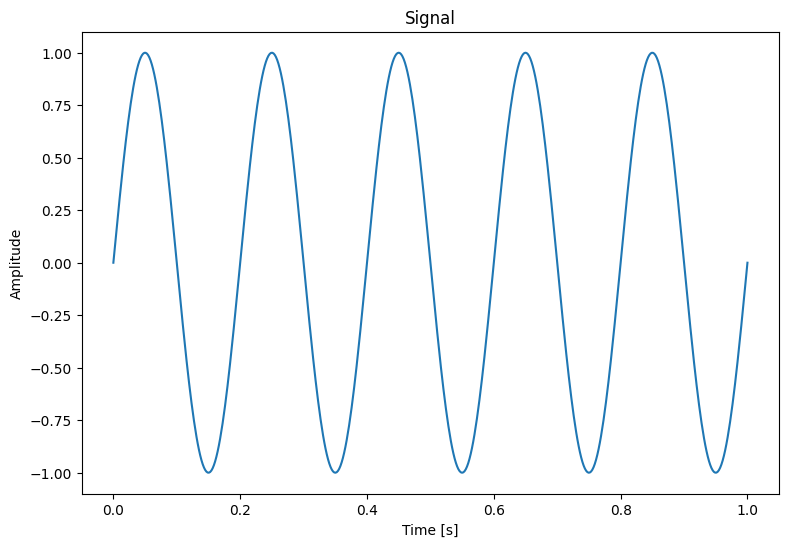

In [21]:
f = 5.0 # [Hz]
sampling_rate = 512
t = np.linspace( 0, 1, sampling_rate ) # [0, 1] [s]
y = np.sin( 2*np.pi*f*t ) # w = 2*pi*f

ax = plt.axes()
ax.plot( t, y )
plt.title( 'Signal' )
plt.xlabel( 'Time [s]' )
plt.ylabel( 'Amplitude' )

Para poder obtener el espectro de la señal sinusoidal, aplicaremos la FFT mediante la función fft de la biblioteca numpy.

In [22]:
spectrum = np.fft.fft( y )
print( 'y = sin(t) -> dim: %s' % (str(y.shape)) )
print( 'FFT(y)     -> dim: %s' % (str(spectrum.shape)) )

y = sin(t) -> dim: (512,)
FFT(y)     -> dim: (512,)


Debido a que el vector de salida de la FFT está compuesto por el espectro tanto de frecuencias positivas, y luego negativas, no podemos graficar este vector para frecuencias continuamente crecientes. Para obtener un vector de frecuencias que esté en concordancia con la salida de la FFT, utilizaremos la función fftfreq de numpy, tal como vemos a continuación.

In [23]:
# sample_frequencies = fftfreq( n = window_length, d = sample_spacing )

freq_bins = np.fft.fftfreq( spectrum.size, d = 1/float(sampling_rate) )

Text(0.5, 1.0, 'Power spectrum')

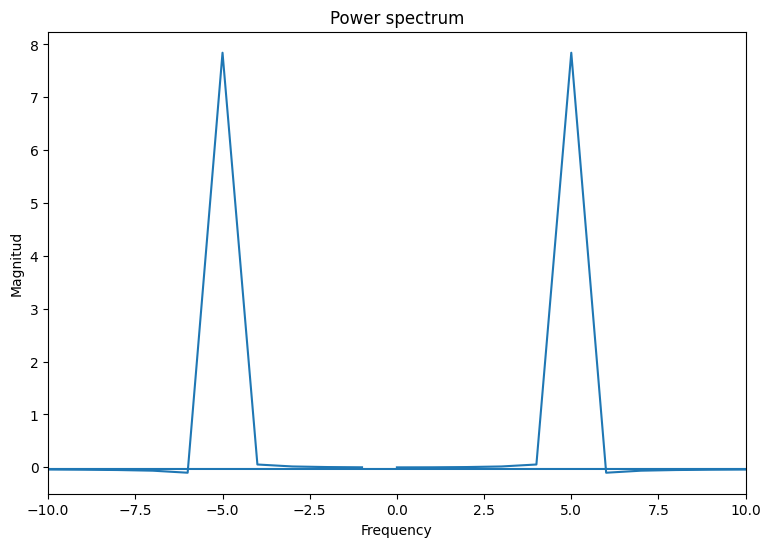

In [24]:
plt.plot(freq_bins, spectrum.real)
plt.xlim( (-10, 10) )
plt.xlabel( 'Frequency' )
plt.ylabel( 'Magnitud' )
plt.title( 'Power spectrum' )

## Serie de Fourier

En esta sección, calcularemos la serie de Fourier trigonométrica para un grupo de señales periódicas, para las cuales hemos calculado sus coeficientes $a_{0}$, $a_{k}$ y $b_{k}$ según las ecuaciones que se ven a continuación:


$\hat{f}(t) = \frac{a_{0}}{2} + \sum_{n=1}^{\infty} \left[ a_{n} \cdot cos(\frac{2 \pi}{T} n t) + b_{n} \cdot sin(\frac{2 \pi}{T} n t) \right]$

$a_{0} = \frac{1}{T} \int_{-\frac{T}{2}}^{\frac{T}{2}} f(t) dt$

$a_{n} = \frac{2}{T} \int_{-\frac{T}{2}}^{\frac{T}{2}} f(t) cos(\frac{2 \pi}{T} n t) dt$

$b_{n} = \frac{2}{T} \int_{-\frac{T}{2}}^{\frac{T}{2}} f(t) sin(\frac{2 \pi}{T} n t) dt$

Comenzaremos por definir la función "generate_animation" que nos permitirá generar una animación con la evolución de la señal que estamos aproximando, en la medidad que vamos agregando componentes armónicos de mayor frecuencia (k cada vez mayor).

In [25]:
import time
from matplotlib import animation, rc

def generate_animation(x, y_history, freq_bins, history_freq):

  fig, (ax1, ax2) = plt.subplots( 2 )

  # Cerramos el gráfico creado porque luego se creará uno con otra función
  # específica para animar
  plt.close()

  ax1.set_ylim( (-2.5, 2.5) )
  ax2.set_xlim( (-100, 100) )

  graph1, = ax1.plot( x, y_history[0] )
  graph2, = ax2.plot( freq_bins, history_freq[0] )

  def animate(i):
    graph1.set_data( x, y_history[i] )
    graph2.set_data( freq_bins, history_freq[i] )

  anim = animation.FuncAnimation( fig, animate, frames = len(y_history) )

  # Este código es para que funcione en google colab
  rc( 'animation', html = 'jshtml' )

  return anim

### Señal cuadrada

A continuación se presentan los coeficientes de la serie de Fourier trigonométrica para una señal cuadrada impar y centrada en cero.


$a_{0} = 0$

$a_{n} = 0$

$b_{n} = \frac{4}{n \cdot \pi} \cdot \left\{
  \begin{array}{ll}
    0 & if \; n \; even \\
    1 & if \; n \; odd
  \end{array}
\right.$

$f(t) = \frac{4}{\pi} \cdot \sum_{n=1, 3, 5,...}^{\infty} \frac{1}{n} \cdot sin( n \cdot 2 \cdot \pi \cdot f \cdot t)$

In [26]:
import copy

f = 5.0 # [Hz]
sampling_rate = 512
t = np.linspace( 0, 1, sampling_rate ) # [0, 1] [s]
y = np.zeros( t.shape )

history = list()
history_freq = list()

for i in range( 1, 200, 2 ):
  y += (4/np.pi) * (1/float(i)) * np.sin( i*2*np.pi*f*t )
  history.append( copy.copy( y ) )
  fft = np.fft.fft( y )
  spectrum = np.abs( fft )
  history_freq.append( copy.copy( spectrum.real ) )

freq_bins = np.fft.fftfreq( spectrum.size, d = 1/float(sampling_rate) )

generate_animation(t, history, freq_bins, history_freq)

Output hidden; open in https://colab.research.google.com to view.

### Señal triangular

A continuación se presentan los coeficientes de la serie de Fourier trigonométrica para una señal triagular impar y centrada en cero.


$a_{0} = 0$

$a_{n} = 0$

$b_{n} = \frac{8}{\pi^2 \cdot n^2} \cdot \left\{
  \begin{array}{lc}
    (-1)^{(n-1)/2} & if \; n \; odd \\ \\
    0 & if \; n \; even
  \end{array}
\right.$

$f(t) = \frac{8}{\pi^2} \cdot \sum_{n=1, 3, 5,...}^{\infty} \frac{(-1)^{(n-1)/2}}{n^2} \cdot sin ( n \cdot 2 \cdot \pi \cdot f \cdot t)$

In [27]:
import copy

f = 5.0 # [Hz]
sampling_rate = 512
t = np.linspace( 0, 1, sampling_rate ) # [0, 1] [s]
y = np.zeros( t.shape )

history = list()
history_freq = list()

for i in range( 1, 20, 2 ):
  y += (8/(np.pi**2)) * (((-1)**((i-1)/2))/float(i**2)) * np.sin( i*2*np.pi*f*t )
  history.append( copy.copy( y ) )
  fft = np.fft.fft( y )
  spectrum = np.abs( fft )
  history_freq.append( copy.copy( spectrum.real ) )

freq_bins = np.fft.fftfreq( spectrum.size, d = 1/float(sampling_rate) )

generate_animation(t, history, freq_bins, history_freq)

### Señal diente de sierra (sawthoot)

A continuación se presentan los coeficientes de la serie de Fourier trigonométrica para una señal diente de sierra impar y no centrada en cero.

$a_{0} = 1$

$a_{n} = 0$

$b_{n} = - \frac{1}{n \cdot \pi}$

$f(t) = \frac{1}{2} - \frac{1}{\pi} \cdot \sum_{n=1}^{\infty} \frac{1}{n} \cdot sin ( n \cdot 2 \cdot \pi \cdot f \cdot t)$

In [28]:
import copy

f = 5.0 # [Hz]
sampling_rate = 512
t = np.linspace( 0, 1, sampling_rate ) # [0, 1] [s]
y = np.zeros( t.shape )

history = list()
history_freq = list()

y += 1/2.0
for i in range( 1, 100 ):
  y += - (1/np.pi) * (1/float(i)) * np.sin( i*2*np.pi*f*t )
  history.append( copy.copy( y ) )
  fft = np.fft.fft( y )
  spectrum = np.abs( fft )
  history_freq.append( copy.copy( spectrum.real ) )

freq_bins = np.fft.fftfreq( spectrum.size, d = 1/float(sampling_rate) )

generate_animation(t, history, freq_bins, history_freq)

Output hidden; open in https://colab.research.google.com to view.

## Actividades

###Actividad 1.1

Calcule los coeficientes de la serir de Fourier trigonométrica para una señal cuadrada impar, de valor mínimo 0 y valor máximo 2 (no centrada en cero), tal como la que aparece abajo en la figura. Luego, programe una rutina para generar una animación en la cual se vea su formación en la medida que se van agregando componentes armónicos a la serie.

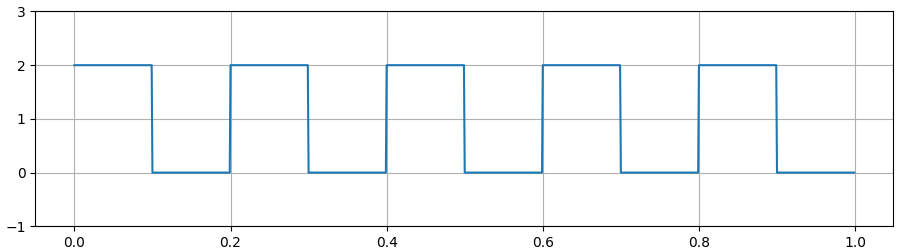

#### Derivación de los coeficientes de Fourier

**Idea clave:** la señal cuadrada con valores 0 y 2 es simplemente la señal cuadrada centrada en cero (valores -1 y +1) del ejemplo anterior, pero desplazada **+1 unidad hacia arriba**.

$$f(t) = \underbrace{1}_{\text{desplazamiento DC}} + \underbrace{g(t)}_{\text{señal cuadrada centrada en cero}}$$

Esto modifica los coeficientes de la siguiente manera:

| Coeficiente | Señal centrada (ejemplo) | Señal desplazada (actividad) |
|:-----------:|:------------------------:|:-----------------------------:|
| $a_0$       | $0$                      | $2$ &nbsp; *(valor medio × 2 = 1 × 2)* |
| $a_n$       | $0$                      | $0$ *(sin cosenos)* |
| $b_n$       | $\dfrac{4}{n\pi}$ si $n$ impar | $\dfrac{4}{n\pi}$ si $n$ impar *(igual)* |

La serie de Fourier completa resulta:

$$f(t) = \underbrace{1}_{a_0/2} + \frac{4}{\pi} \sum_{n=1,3,5,\ldots}^{\infty} \frac{1}{n} \cdot \sin\!\left(n \cdot 2\pi \cdot f \cdot t\right)$$

> **Nota:** el único cambio respecto al ejemplo es agregar la constante **+1** (componente DC). Los armónicos senoidales son exactamente los mismos.

In [29]:
import copy

# ─── Parámetros básicos ───────────────────────────────────────────────────────
f             = 5.0           # Frecuencia fundamental [Hz]
sampling_rate = 512           # Muestras por segundo [Hz]
t = np.linspace(0, 1, sampling_rate)   # Vector de tiempo: 0 a 1 segundo

# ─── Señal inicial ────────────────────────────────────────────────────────────
y = np.zeros(t.shape)   # Comenzamos con la señal en cero

history       = list()  # Guardará la señal acumulada en cada iteración
history_freq  = list()  # Guardará el espectro en cada iteración

# ─── Componente DC (término a0/2 = 1) ─────────────────────────────────────────
# Este término desplaza la señal +1 unidad, cambiando el rango de [-1,1] a [0,2]
y += 1.0

# ─── Suma de armónicos impares ────────────────────────────────────────────────
# La fórmula es: (4/π) · Σ (1/n) · sin(n·2π·f·t) para n = 1, 3, 5, ...
# Nota: range(1, 200, 2) genera n = 1, 3, 5, ..., 199  (solo impares)
for i in range(1, 200, 2):

    # Sumamos el i-ésimo armónico con su coeficiente bn = 4/(i·π)
    y += (4 / np.pi) * (1 / float(i)) * np.sin(i * 2 * np.pi * f * t)

    # Guardamos una copia de la señal acumulada hasta este momento
    history.append(copy.copy(y))

    # Calculamos el espectro de la señal actual mediante FFT
    fft      = np.fft.fft(y)
    spectrum = np.abs(fft)          # Magnitud del espectro (parte real del módulo)
    history_freq.append(copy.copy(spectrum.real))

# ─── Vector de frecuencias para el eje x del espectro ────────────────────────
freq_bins = np.fft.fftfreq(spectrum.size, d=1 / float(sampling_rate))

# ─── Generamos la animación ───────────────────────────────────────────────────
# El gráfico superior muestra cómo la señal se aproxima a la cuadrada desplazada.
# El gráfico inferior muestra el espectro: barras en 0, 5, 15, 25, 35... [Hz]
generate_animation(t, history, freq_bins, history_freq)

Output hidden; open in https://colab.research.google.com to view.

###Actividad 1.2

Responda la siguiente pregunta: ¿ En qué se diferencia el **espectro** de la señal cuadrada entregada en el ejemplo (centrada de cero), de la solicitada en la actividad 1.1 ?

**Respuesta:**

Ambas señales (la centrada en cero y la desplazada de 0 a 2) comparten los mismos armónicos senoidales, pero se diferencian en **un único aspecto**:

| Característica del espectro | Señal centrada (ejemplo) | Señal desplazada (actividad 1.1) |
|:---------------------------|:------------------------:|:--------------------------------:|
| Componente DC (frecuencia 0) | ❌ Ausente | ✅ Presente (magnitud proporcional al desplazamiento +1) |
| Armónico fundamental (5 Hz) | ✅ Presente | ✅ Presente (misma magnitud) |
| Armónicos impares (15, 25, 35... Hz) | ✅ Presentes | ✅ Presentes (misma magnitud) |
| Armónicos pares (10, 20, 30... Hz) | ❌ Ausentes | ❌ Ausentes |

**En palabras simples:** añadir un desplazamiento constante a una señal solo agrega energía en la frecuencia **0 Hz** (corriente continua o DC). Las demás frecuencias quedan intactas porque el desplazamiento es una constante, y las constantes no oscilan a ninguna frecuencia.

> **Analogía:** imagina que elevas toda la forma de onda verticalmente. La forma (y por tanto su contenido en frecuencia) no cambia; solo agregas un "nivel base" que aparece en 0 Hz del espectro.

#Análisis tiempo-frecuencia

##Short-time fourier transform (STFT)

###STFT sobre un grupo de señales sinusoidales

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import pylab

import resampy
import librosa
import librosa.display

%matplotlib inline
pylab.rcParams['figure.figsize'] = 12,6 # default: [6, 4]

Text(0, 0.5, 'Amplitude')

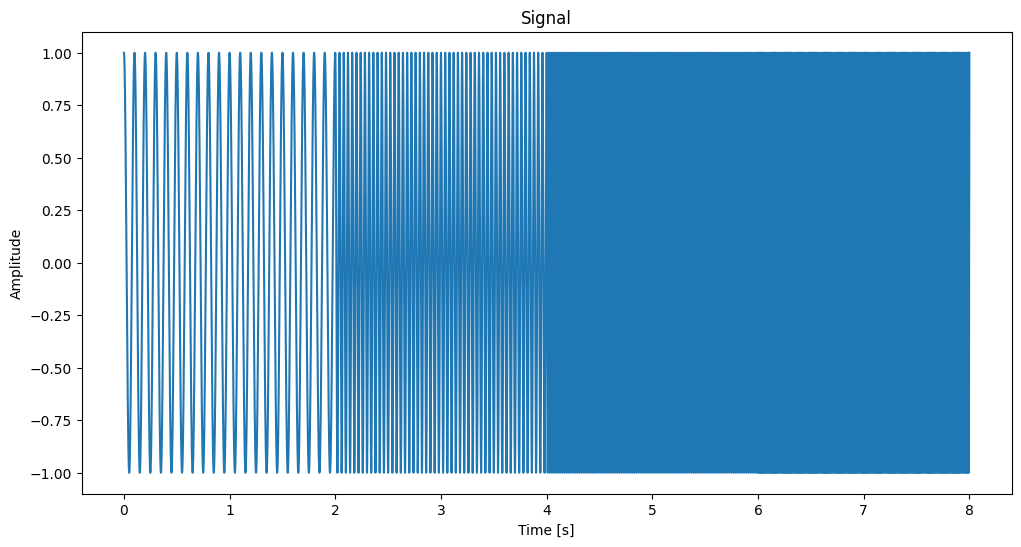

In [31]:
sampling_rate = 8192
t = np.linspace( 0, 8, 8*sampling_rate ) # [0, 8] [s]
dt = int(len(t)/4)

y1 = np.cos( 2*np.pi*10*t[0*dt:1*dt] ) # 10 [Hz]
y2 = np.cos( 2*np.pi*25*t[1*dt:2*dt] ) # 25 [Hz]
y3 = np.cos( 2*np.pi*50*t[2*dt:3*dt] ) # 50 [Hz]
y4 = np.cos( 2*np.pi*100*t[3*dt:4*dt] ) # 100 [Hz]
y = np.concatenate( (y1, y2, y3, y4) )

ax = plt.axes()
scat = ax.plot( t, y )
plt.title( 'Signal' )
plt.xlabel( 'Time [s]' )
plt.ylabel( 'Amplitude' )

(1025, 129)


[Text(0.5, 1.0, 'STFT')]

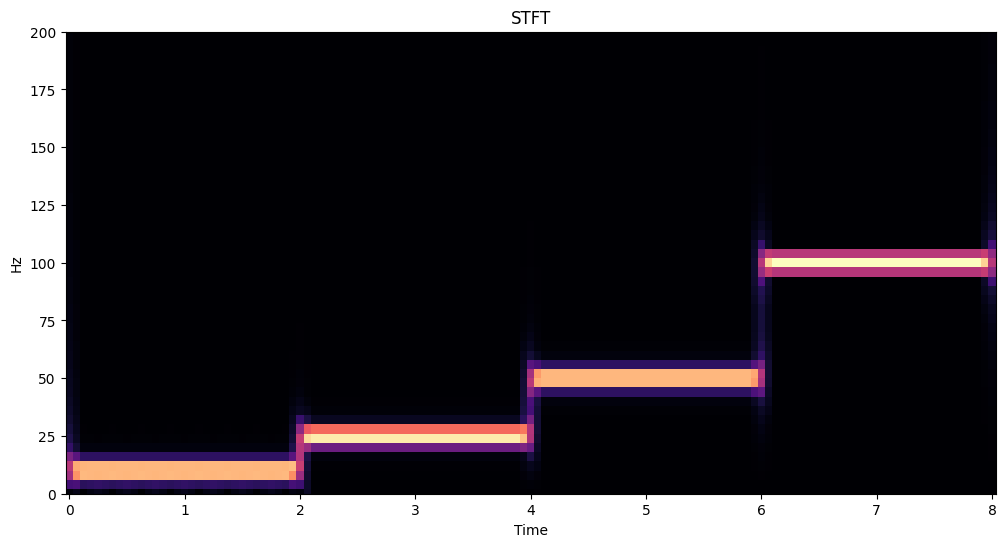

In [32]:
spec = np.abs( librosa.stft( y ) )
print( spec.shape )

fig, ax = plt.subplots()
img = librosa.display.specshow( spec, x_axis = 'time', y_axis = 'linear', sr = sampling_rate, ax = ax ) # librosa default sr 22kHz
ax.set_ylim( [0, 200] )
ax.set( title = 'STFT' )

###STFT sobre un archivo de audio

In [36]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving 100652-3-0-0.wav to 100652-3-0-0 (2).wav
User uploaded file "100652-3-0-0 (2).wav" with length 705644 bytes


In [37]:
audio_data, sampling_rate = librosa.load( '100652-3-0-0.wav' )
print('Audio file sampling rate: %d [Hz]' % (sampling_rate))

Audio file sampling rate: 22050 [Hz]


In [38]:
ipd.Audio( audio_data, rate = sampling_rate )

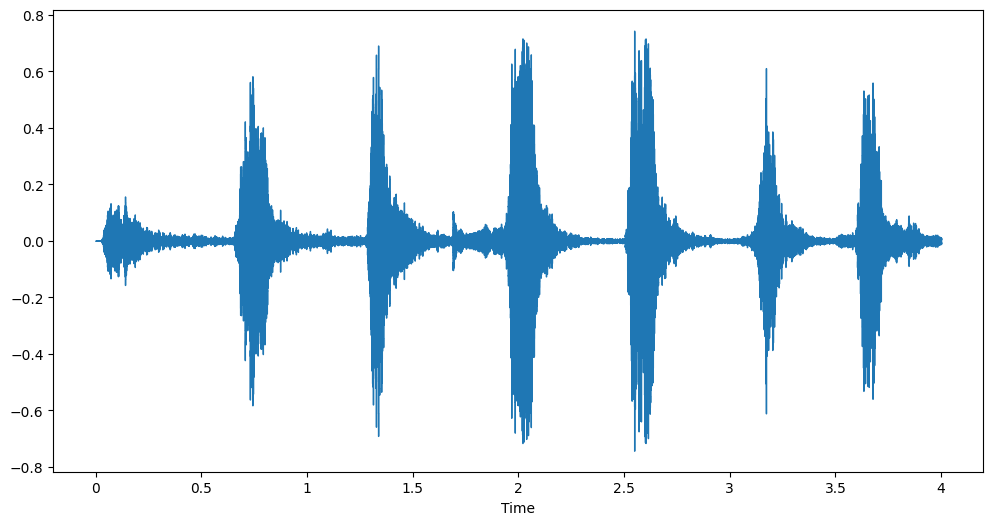

In [39]:
librosa.display.waveshow( audio_data, sr = sampling_rate )

In [40]:
spec = librosa.stft( audio_data )
spec_db = librosa.amplitude_to_db( np.abs( spec ), ref = np.max ) # 20*log( x / ref )

[Text(0.5, 1.0, 'Audio signal STFT')]

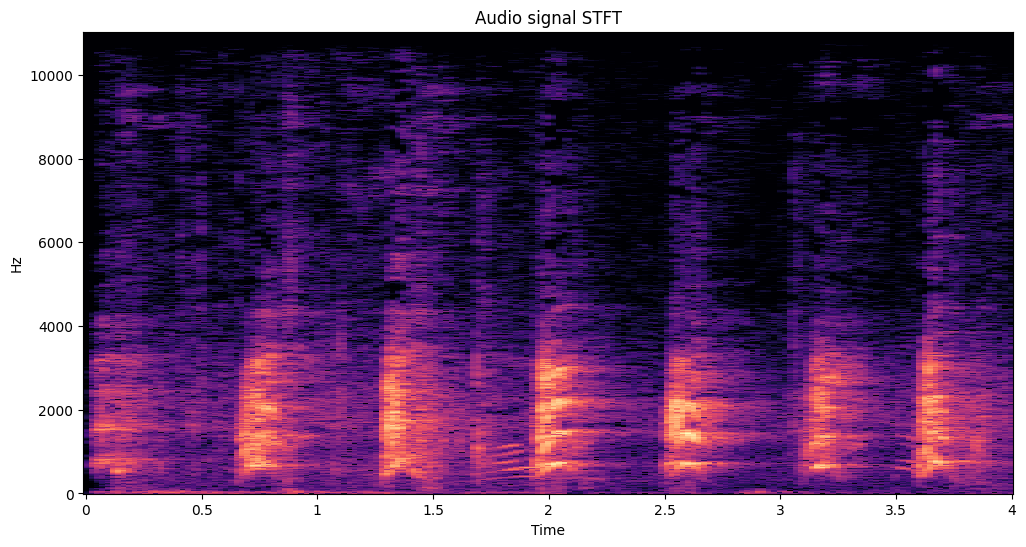

In [41]:
fig, ax = plt.subplots()
img = librosa.display.specshow( spec_db, x_axis='time', y_axis='linear', sr = sampling_rate, ax=ax )
ax.set( title = 'Audio signal STFT' )

##Mel Scale based transformations

###Mel Spectrogram

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import pylab

import resampy
import librosa
import librosa.display

%matplotlib inline
pylab.rcParams['figure.figsize'] = 12,6 # default: [6, 4]

Text(0, 0.5, 'Amplitude')

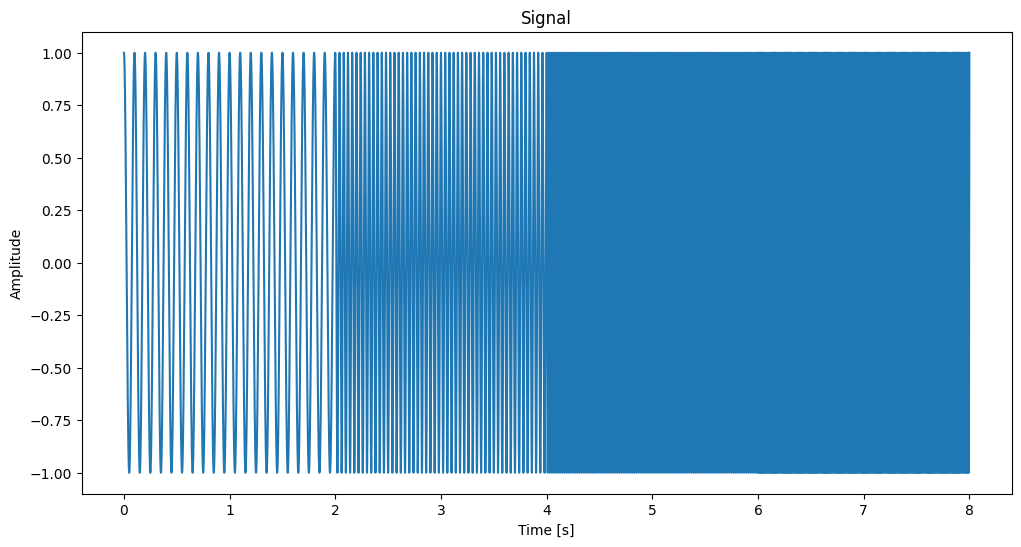

In [43]:
sampling_rate = 8192
t = np.linspace( 0, 8, 8*sampling_rate ) # [0, 8] [s]
dt = int(len(t)/4)

y1 = np.cos( 2*np.pi*10*t[0*dt:1*dt] ) # 10 [Hz]
y2 = np.cos( 2*np.pi*25*t[1*dt:2*dt] ) # 25 [Hz]
y3 = np.cos( 2*np.pi*50*t[2*dt:3*dt] ) # 50 [Hz]
y4 = np.cos( 2*np.pi*100*t[3*dt:4*dt] ) # 100 [Hz]
y = np.concatenate( (y1, y2, y3, y4) )

ax = plt.axes()
scat = ax.plot( t, y )
plt.title( 'Signal' )
plt.xlabel( 'Time [s]' )
plt.ylabel( 'Amplitude' )

(256, 129)


/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


[Text(0.5, 1.0, 'Mel-frequency spectrogram')]

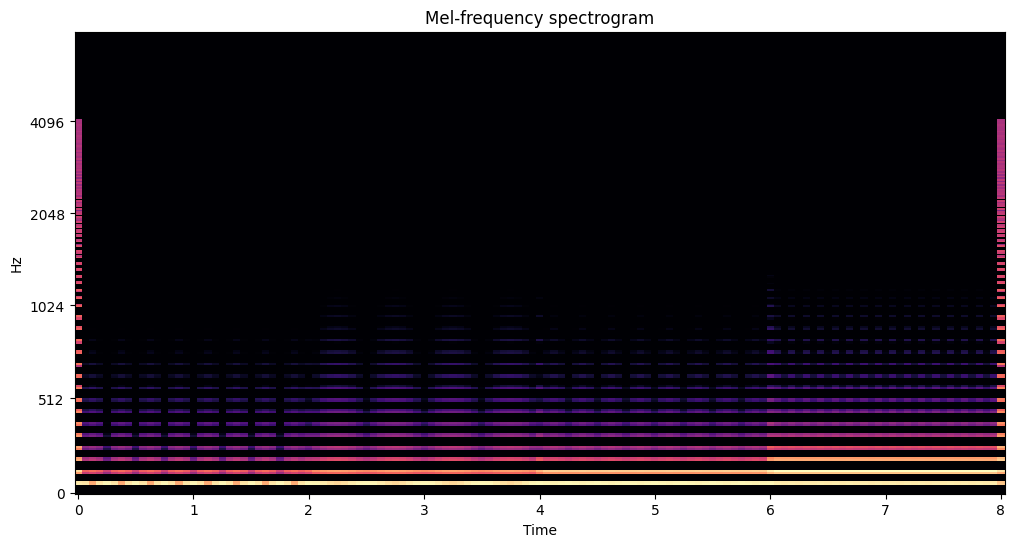

In [44]:
S = librosa.feature.melspectrogram( y = y, sr = sampling_rate, n_mels = 256, n_fft = 128, fmax = 8000 )
S_dB = librosa.power_to_db( S, ref = np.max ) # 10*log( x / ref )
print(S.shape)
fig, ax = plt.subplots()
img = librosa.display.specshow(S_dB, x_axis = 'time', y_axis = 'mel', sr=sampling_rate, fmax=8000, ax=ax)
ax.set(title='Mel-frequency spectrogram')

###Mel-frequency Cepstral Coefficients (MFCC)

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import pylab

import resampy
import librosa
import librosa.display

%matplotlib inline
pylab.rcParams['figure.figsize'] = 12,6 # default: [6, 4]

Text(0, 0.5, 'Amplitude')

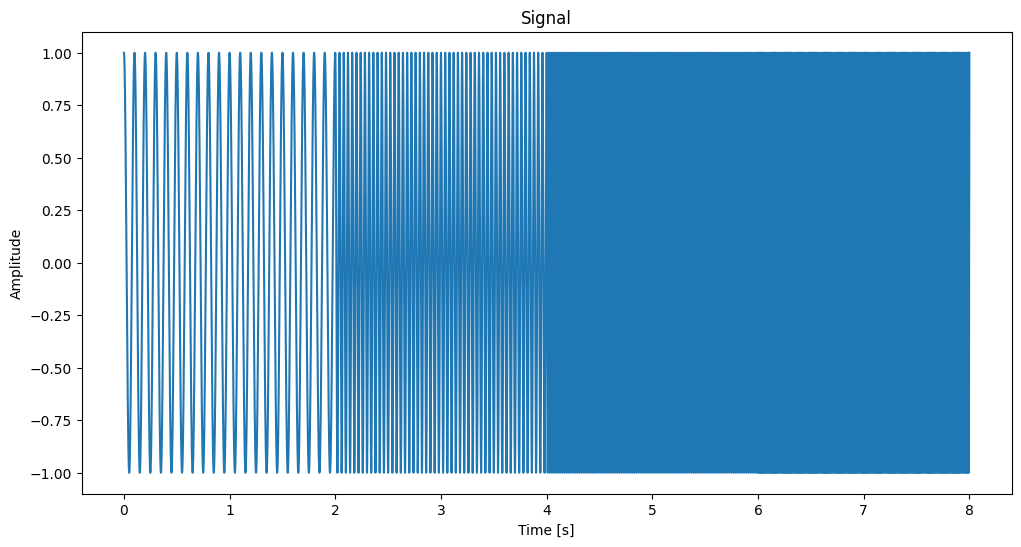

In [46]:
sampling_rate = 8192
t = np.linspace( 0, 8, 8*sampling_rate ) # [0, 8] [s]
dt = int(len(t)/4)

y1 = np.cos( 2*np.pi*10*t[0*dt:1*dt] ) # 10 [Hz]
y2 = np.cos( 2*np.pi*25*t[1*dt:2*dt] ) # 25 [Hz]
y3 = np.cos( 2*np.pi*50*t[2*dt:3*dt] ) # 50 [Hz]
y4 = np.cos( 2*np.pi*100*t[3*dt:4*dt] ) # 100 [Hz]
y = np.concatenate( (y1, y2, y3, y4) )

ax = plt.axes()
scat = ax.plot( t, y )
plt.title( 'Signal' )
plt.xlabel( 'Time [s]' )
plt.ylabel( 'Amplitude' )

(40, 129)


[Text(0.5, 1.0, 'MFCC')]

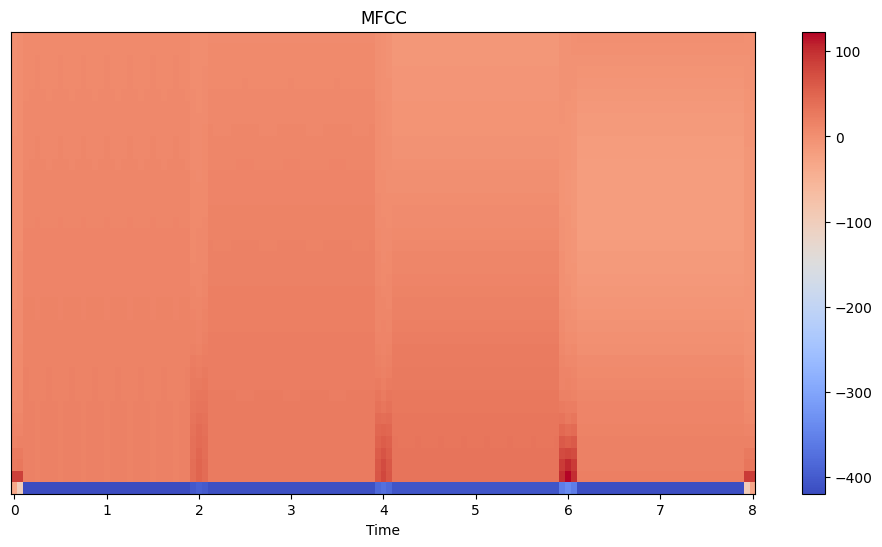

In [47]:
mfccs = librosa.feature.mfcc( y = y, sr = sampling_rate, n_mfcc = 40 )
print(mfccs.shape)

fig, ax = plt.subplots()
img = librosa.display.specshow( mfccs, x_axis = 'time', sr = sampling_rate, fmax = 8000, ax = ax )
fig.colorbar(img, ax=ax)
ax.set(title='MFCC')

###MFCC sobre un archivo de audio

In [48]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving 100652-3-0-0.wav to 100652-3-0-0 (3).wav
User uploaded file "100652-3-0-0 (3).wav" with length 705644 bytes


In [49]:
audio_data, sampling_rate = librosa.load( '100652-3-0-0.wav' )
print('Audio file sampling rate: %d [Hz]' % (sampling_rate))

Audio file sampling rate: 22050 [Hz]


In [50]:
ipd.Audio( audio_data, rate = sampling_rate )

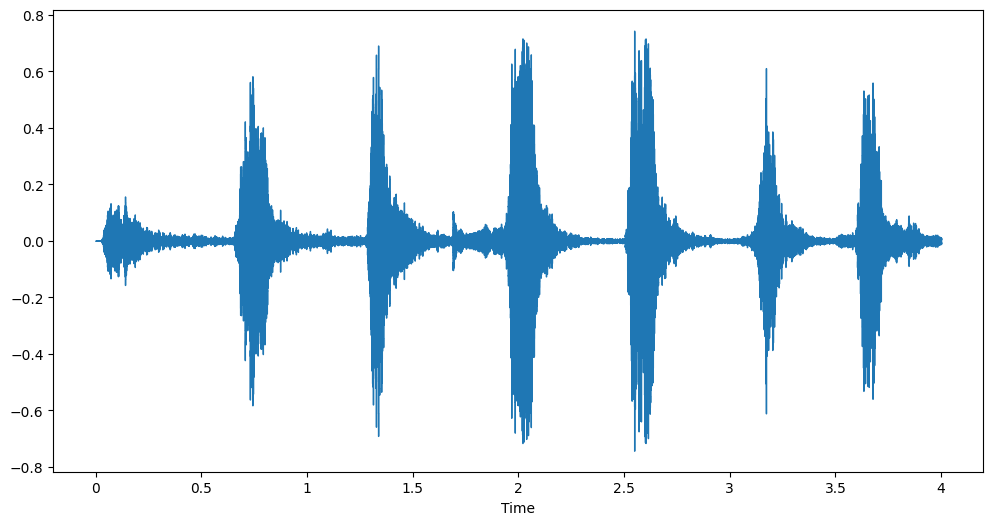

In [51]:
librosa.display.waveshow( audio_data, sr = sampling_rate )

(40, 173)


[Text(0.5, 1.0, 'MFCC')]

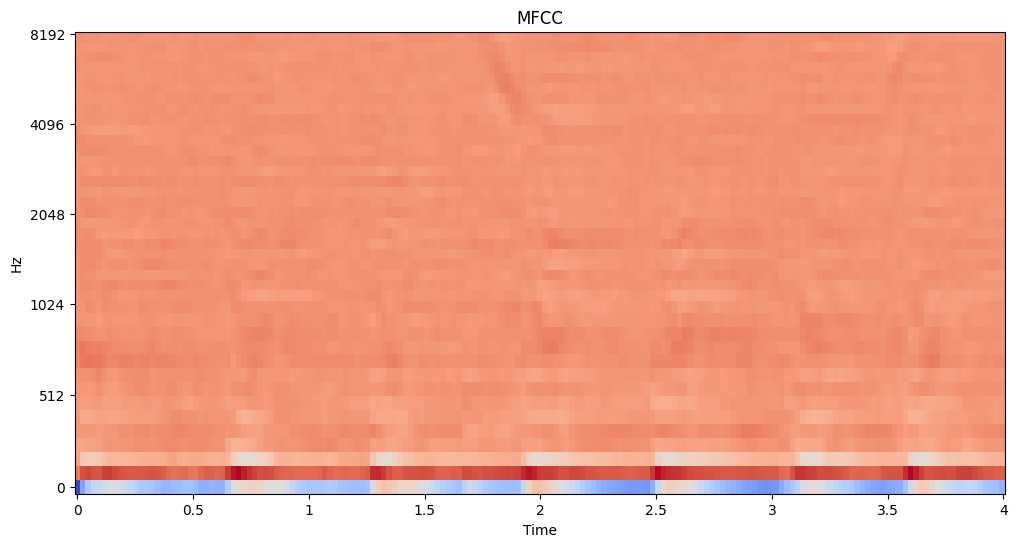

In [52]:
mfccs = librosa.feature.mfcc( y = audio_data, sr = sampling_rate, n_mfcc = 40 )
print( mfccs.shape )

fig, ax = plt.subplots()
img = librosa.display.specshow( mfccs, x_axis = 'time', y_axis = 'mel', sr = sampling_rate, fmax = 8000, ax = ax )
ax.set(title='MFCC')

##Actividades

###Actividad 2.1

Responda la siguiente pregunta: Cuando utilizamos transformaciones basadas en ventanas temporales como en el caso de STFT, ¿ cuál es el efecto sobre la precisión de la frecuencia cuando aumentamos el tamaño de la ventana ?

**Respuesta:**

Al aumentar el tamaño de la ventana temporal en la STFT, la **precisión en frecuencia mejora**, pero a un costo: la **precisión en tiempo empeora**.

Esto se explica por el **principio de incertidumbre tiempo-frecuencia** (análogo al principio de Heisenberg en física):

$$\Delta t \;\cdot\; \Delta f \;\geq\; \text{constante}$$

Es decir, no se puede tener alta resolución en tiempo **y** en frecuencia al mismo tiempo.

| Tamaño de ventana | Resolución en frecuencia | Resolución en tiempo | ¿Cuándo usarlo? |
|:-----------------:|:------------------------:|:--------------------:|:---------------:|
| **Grande** | Alta ✅ (distingo frecuencias cercanas) | Baja ❌ (no sé exactamente cuándo ocurre) | Señales con frecuencias fijas y estables |
| **Pequeña** | Baja ❌ (difícil separar frecuencias) | Alta ✅ (detecto cambios rápidos en el tiempo) | Señales que cambian rápidamente |

**Intuición geométrica:** para medir con precisión cuántos ciclos por segundo tiene una onda (frecuencia), necesitas observarla durante **mucho tiempo**. Si solo la observas un instante, no puedes saber si vibra a 99 Hz o a 101 Hz. Pero si la observas mucho tiempo, ya no sabes en qué instante exacto ocurrió un evento.

> **Ejemplo práctico:** en el espectrograma de la señal con 4 frecuencias distintas (10, 25, 50 y 100 Hz), una ventana grande separa mejor cada frecuencia (líneas más nítidas en el eje vertical), pero los bordes entre los 4 segmentos se ven borrosos (eje horizontal).